In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [2]:
api = wandb.Api()

In [13]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s13/experiments/distillation-layerwise/run1"

In [49]:
def read_data(
    teacher,
    student,
    basis_name,
    lambda_task,
    lambda_kd,
    lambda_layer,    
    training_size,
    verbose=False
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.lambda_layer": lambda_layer},
            {"config.basis_name": basis_name},
            {"config.training_size": training_size},

        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
                
        for i, (val_acc, val_agreement) in enumerate(
            zip(
                run.summary["arr_metrics"]["val_acc"],
                run.summary["arr_metrics"]["val_agreement"],
            )
        ):
            rows.append(
                dict(
                    seed=seed, 
                    epoch=i,
                    val_acc=val_acc, 
                    val_agreement=val_agreement,
                    teacher_acc=run.summary["teacher_acc"]
                )
            )

    
    df = pd.DataFrame(rows)
        
    df = df.groupby(by="epoch").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "teacher_acc": ["mean", "std"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-wb15",
    student="resnet18compr2",
    
    lambda_task=0.0,
    lambda_kd=1.0,
    lambda_layer=1.0,

    basis_name="pca",
    training_size=1.0,
    verbose=True
)

summary

we have 20 runs
df.shape: (101, 9)


epoch   val_acc                 val_agreement                 teacher_acc  \
               mean       std count          mean       std count        mean   
0       0  0.211328  0.028953    20      0.204687  0.032321    20      0.8717   
1       1  0.473500  0.083985    20      0.479100  0.083279    20      0.8717   
2       2  0.538900  0.084812    20      0.548200  0.083161    20      0.8717   
3       3  0.574600  0.095008    20      0.581800  0.088963    20      0.8717   
4       4  0.608000  0.100791    20      0.615700  0.094682    20      0.8717   
..    ...       ...       ...   ...           ...       ...   ...         ...   
96     96  0.830900  0.087687    20      0.839600  0.080735    20      0.8717   
97     97  0.828700  0.091730    20      0.839100  0.080604    20      0.8717   
98     98  0.829500  0.091223    20      0.839900  0.081480    20      0.8717   
99     99  0.828900  0.093301    20      0.837900  0.080214    20      0.8717   
100   100  0.830900  0.091425    20      0.839100  0.082845    20      0.8717   

               
          std  
0    0.077496  
1    0.077496  
2    0.077496  
3    0.077496  
4    0.077496  
..        ...  
96   0.077496  
97   0.077496  
98   0.077496  
99   0.077496  
100  0.077496  

[101 rows x 9 columns]

# Viz Distillation Over 20 Classes

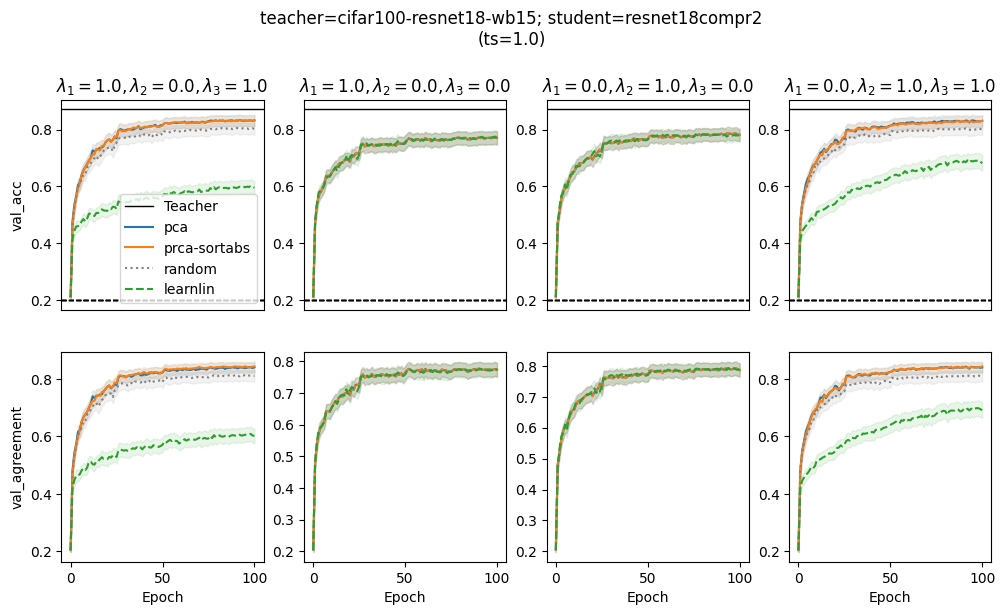

In [81]:
def ls(basis_name):
    if basis_name == "random":
        return ":"
    elif basis_name == "learnlin":
        return "--"
    else:
        return "-"
    
def color(basis_name):
    if basis_name == "random":
        return "gray"
    else:
        return None
    
def viz_distillation(arr_lambdas, training_size):
    
    teacher = "cifar100-resnet18-wb15"
    student = "resnet18compr2"
    
    basis_names = [ 
        "pca",
        "prca-sortabs",
        "random",
        "learnlin"
    ]
        
    ncols = len(arr_lambdas)
    nrows = 2
    
    plt.figure(figsize=(3*ncols, 3*2))
    
    plt.suptitle(
        "\n".join([
            f"teacher={teacher}; student={student}",
            f"(ts={training_size})"
        ]),
        y=1.03
    )
    
    for lix, (lambda_task, lambda_kd, lambda_layer) in enumerate(arr_lambdas):
        for cix, col in enumerate(["val_acc", "val_agreement"]):
            plt.subplot(nrows, ncols, cix * ncols + lix + 1)
            for bix, basis_name in enumerate(basis_names):
                
                df = read_data(
                    teacher=teacher,
                    student=student,

                    lambda_task=lambda_task,
                    lambda_kd=lambda_kd,
                    lambda_layer=lambda_layer,

                    basis_name=basis_name,
                    training_size=training_size,
                    verbose=False
                )
                
                
                if cix == 0:
                    plt.title(f"$\lambda_1={lambda_task},\lambda_2={lambda_kd},\lambda_3={lambda_layer}$")
                    plt.xticks([])
                    teacher_acc = df["teacher_acc"]["mean"][0]
                    plt.axhline(0.2, ls="--", lw=1, color="k")
                    if bix == 0:
                        plt.axhline(
                            teacher_acc,
                            label="Teacher",
                            color="k",
                            lw=1
                        )
                    
                epochs = df["epoch"]
                metric_mean = df[col]["mean"]
                metric_stderr = df[col]["std"] / (df[col]["count"] ** 0.5)
                plt.plot(
                    epochs,
                    metric_mean,
                    label=basis_name,
                    ls=ls(basis_name),
                    color=color(basis_name)
                )
                plt.fill_between(
                    epochs,
                    metric_mean-metric_stderr,
                    metric_mean+metric_stderr,
                    color=plt.gca().lines[-1].get_color(),
                    alpha=0.1
                )
    

                
                    
            if lix == 0:
                plt.ylabel(col)
                
                if cix == 0:
                    plt.legend()
                    
            if cix == 1:
                plt.xlabel("Epoch")
            
viz_distillation(
    training_size=1.0,
    arr_lambdas=[
      (1.0, 0.0, 1.0),
      (1.0, 0.0, 0.0),
      (0.0, 1.0, 0.0),
      (0.0, 1.0, 1.0),
    ]
) 

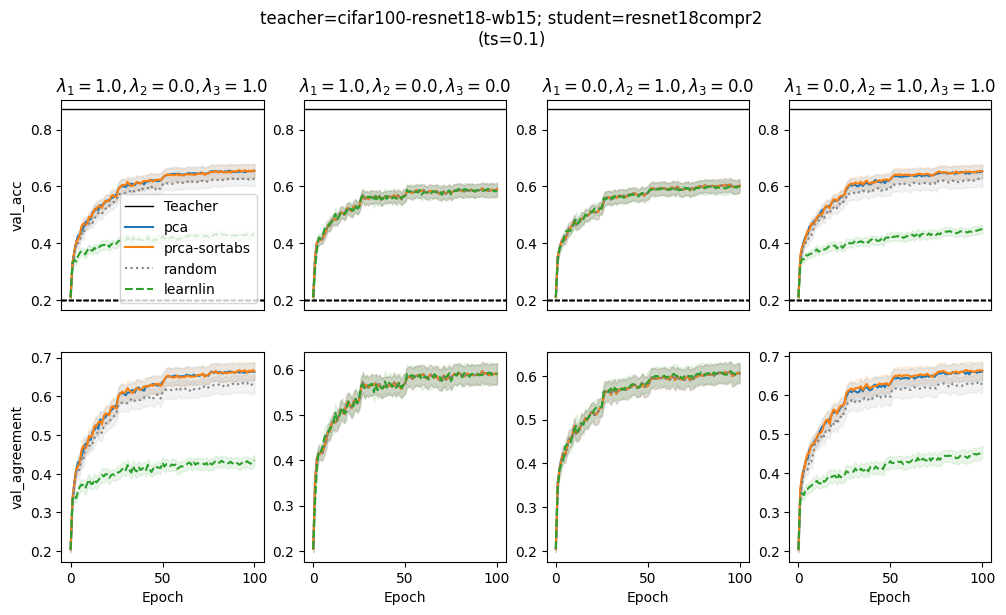

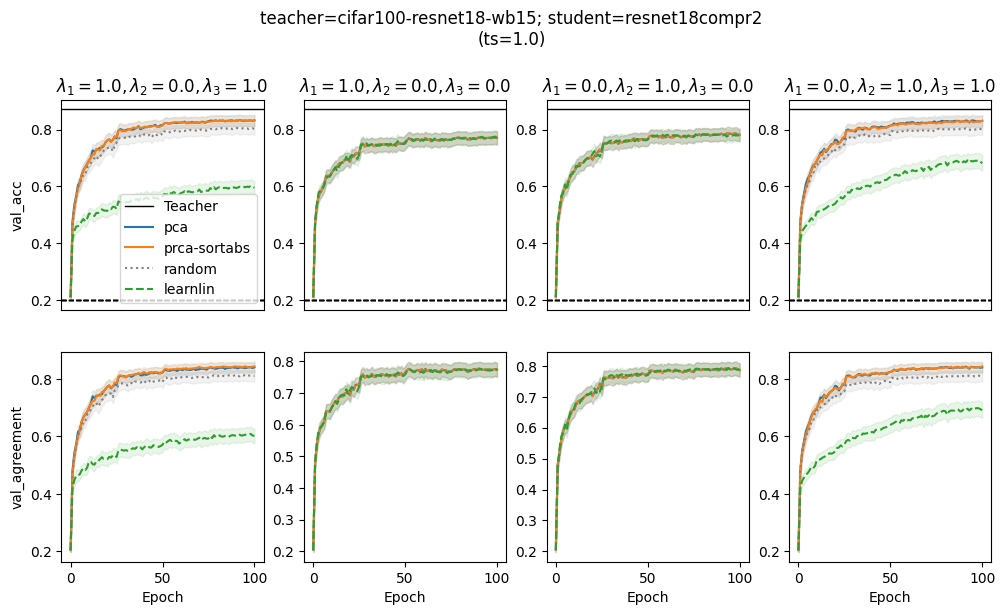

In [85]:
for training_size in [0.1, 1.0]:
    viz_distillation(
        training_size=training_size,
        arr_lambdas=[
          (1.0, 0.0, 1.0),
          (1.0, 0.0, 0.0),
          (0.0, 1.0, 0.0),
          (0.0, 1.0, 1.0),
        ]
    ) 

# Summary

Setup:
$$
 \lambda_1 \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer}
$$

Aims: 
- investigate whether layerwise loss helps improve performance
- investigate whether the effecacy of the task and KD loss.


Conclusion: 
- Without layer loss, using only $\ell_\text{KD}$ seems to be better than using the $\ell_\text{task}$.
- For $\ell_\text{KD}$ and $\ell_\text{task}$, combining with $\ell_\text{layer}$ improve performance when using orthogonal bases but not `learnlin`.

Caveats:
- this results could be confounded by the weighting between $\lambda$'s.

Follow-up:
- why does `learnlin` perform poorly with $\ell_\text{layer}$?
- why does `agreement` look similar to `accuracy`? 
    - Desptie the fact that `val_agreement` is low, `train_agreement` is actuall not that low.
- why could NOT we reach teacher acc?
    - is it because, by splitting subclasses, we do NOT use all the training samples?
        - if this is the case, it is a challenge of subtask distillation in general.